<h1><center>Heart Failure Prediction: Analysis and modeling</center></h1>

<center><img width="800" height="600" src="https://pediatricheartspecialists.com/images/answers/Normal_Heart_Anatomy_and_Blood_Flow.jpg"></center>

<a id="top"></a>

<div class="list-group" id="list-tab" role="tablist">
<h3 class="list-group-item list-group-item-action active" data-toggle="list" style='background:purple; border:0' role="tab" aria-controls="home"><center>Quick navigation</center></h3>

* [1. Data analysis and Visualization](#1)
* [2. Data transformations](#2)
* [3. Modeling](#3)
* [4. Optimization](#4)


Install package for outlier detection algorithms.

In [1]:
!pip install pyod

     |████████████████████████████████| 98 kB 1.0 MB/s 
     |████████████████████████████████| 2.1 MB 4.7 MB/s 
  Created wheel for pyod: filename=pyod-0.8.4-py3-none-any.whl size=112081 sha256=697a0a8ce239c1f7c992877e4bcdca3a432249533c9afff1ee0e604f7263d468
  Stored in directory: /root/.cache/pip/wheels/9f/c9/60/b1311d6e5480f83f29e88bc6223ee1f011e0989a817ad01b65
  Created wheel for combo: filename=combo-0.1.1-py3-none-any.whl size=42113 sha256=8e6a68cd369d3a869c9d15dceaf9e51294b350d180515f4cae31ed730c3ac87c
  Stored in directory: /root/.cache/pip/wheels/3e/e1/f8/08f19ba48f75d3dbbb549cec4b86cc0392c14b2b6bb81f4e1f
  Created wheel for suod: filename=suod-0.0.4-py3-none-any.whl size=2167157 sha256=969dfdeb79c12f64dbac53159b6fabdb122279ad6b6cb526c2a377e4a37146c1
  Stored in directory: /root/.cache/pip/wheels/dc/ae/aa/3b8cc857617f3ba6cb9e6b804c79c69d0ed60a08e022e9a4f3
Successfully built pyod combo suod
You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade

In [2]:
import numpy as np 
import pandas as pd

import seaborn as sns

import plotly.express as px
import plotly.figure_factory as ff

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, confusion_matrix
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import optuna
from optuna.samplers import TPESampler

from pyod.models.copod import COPOD

<a id="1"></a>
<h2 style='background:purple; border:0; color:white'><center>1. Data analysis and Visualization<center><h2>

In [3]:
HEIGHT = 500
WIDTH = 700
NBINS = 50
SCATTER_SIZE=700

In this section we are going to do quick overview of available variables.

In [4]:
df = pd.read_csv('/kaggle/input/heart-failure-clinical-data/heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


Let's see percent of NaNs for every column.

In [5]:
for col in df.columns:
    print(col, str(round(100* df[col].isnull().sum() / len(df), 2)) + '%')

age 0.0%
anaemia 0.0%
creatinine_phosphokinase 0.0%
diabetes 0.0%
ejection_fraction 0.0%
high_blood_pressure 0.0%
platelets 0.0%
serum_creatinine 0.0%
serum_sodium 0.0%
sex 0.0%
smoking 0.0%
time 0.0%
DEATH_EVENT 0.0%


In [6]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [7]:
def plot_histogram(dataframe, column, color, bins, title, width=WIDTH, height=HEIGHT):
    figure = px.histogram(
        dataframe, 
        column, 
        color=color,
        nbins=bins, 
        title=title, 
        width=width,
        height=height
    )
    figure.show()

First we will look at Age distribution.

In [8]:
plot_histogram(df, 'age', 'sex', NBINS, 'Patients age distribution')

In [9]:
plot_histogram(df, 'age', 'DEATH_EVENT', NBINS, 'Patients age distribution')

In [10]:
fig = px.box(
    df, 
    x="DEATH_EVENT", 
    y="age", 
    points='all',
    title='Age & DEATH_EVENT box plot',
    width=WIDTH,
    height=HEIGHT    
)

fig.show()

Now let's check anaemia cases.

In [11]:
ds = df['anaemia'].value_counts().reset_index()

ds.columns = [
    'anaemia', 
    'count'
]

fig = px.pie(
    ds, 
    values='count', 
    names="anaemia", 
    title='Anaemia bar chart', 
    width=WIDTH, 
    height=HEIGHT
)

fig.show()

In [12]:
plot_histogram(
    df, 
    'creatinine_phosphokinase', 
    'DEATH_EVENT', 
    2 * NBINS, 
    'Creatinine phosphokinase distribution'
)

In [13]:
ds = df['diabetes'].value_counts().reset_index()

ds.columns = [
    'diabetes', 
    'count'
]

fig = px.pie(
    ds, 
    values='count', 
    names="diabetes", 
    title='Diabetes bar chart', 
    width=WIDTH, 
    height=HEIGHT
)

fig.show()

In [14]:
fig = px.histogram(
    df, 
    "ejection_fraction", 
    color='DEATH_EVENT',
    nbins=NBINS, 
    title='Ejection_fraction distribution',
    width=WIDTH,
    height=HEIGHT
)

fig.show()

In [15]:
fig = px.box(
    df, 
    x="DEATH_EVENT", 
    y="ejection_fraction", 
    points='all',
    title='Ejection_fraction & DEATH_EVENT box plot',
    width=WIDTH,
    height=HEIGHT
)

fig.show()

In [16]:
ds = df['high_blood_pressure'].value_counts().reset_index()

ds.columns = [
    'high_blood_pressure', 
    'count'
]

fig = px.pie(
    ds, 
    values='count', 
    names="high_blood_pressure", 
    title='High blood pressure bar chart', 
    width=WIDTH, 
    height=HEIGHT
)

fig.show()

In [17]:
fig = px.histogram(
    df, 
    "platelets", 
    nbins=NBINS, 
    color='DEATH_EVENT', 
    title='Platelets distribution',
    width=WIDTH,
    height=HEIGHT
)

fig.show()

In [18]:
fig = px.box(
    df, 
    x="DEATH_EVENT", 
    y="platelets", 
    points='all',
    title='Platelets & DEATH_EVENT box plot',
    width=WIDTH,
    height=HEIGHT
)

fig.show()

In [19]:
fig = px.histogram(
    df, 
    "serum_creatinine", 
    nbins=NBINS, 
    color='DEATH_EVENT',
    title='Serum creatinine distribution',
    width=WIDTH,
    height=HEIGHT
)

fig.show()

In [20]:
fig = px.box(
    df, 
    x="DEATH_EVENT", 
    y="serum_creatinine", 
    points='all',
    title='Serum_creatinine & DEATH_EVENT box plot',
    width=WIDTH,
    height=HEIGHT
)

fig.show()

In [21]:
fig = px.histogram(
    df, 
    "serum_sodium",
    color='DEATH_EVENT',
    nbins=NBINS, 
    title='Serum sodium distribution', 
    width=WIDTH,
    height=HEIGHT
)

fig.show()

In [22]:
fig = px.box(
    df, 
    x="DEATH_EVENT", 
    y="serum_sodium", 
    points='all',
    title='Serum_sodium & DEATH_EVENT box plot',
    width=WIDTH,
    height=HEIGHT
)
   
fig.show()

In [23]:
ds = df['sex'].value_counts().reset_index()

ds.columns = [
    'sex', 
    'count'
]

fig = px.pie(
    ds, 
    values='count', 
    names="sex", 
    title='Gender bar chart', 
    width=WIDTH, 
    height=HEIGHT
)

fig.show()

In [24]:
ds = df['smoking'].value_counts().reset_index()
ds.columns = [
    'smoking', 
    'count'
]

fig = px.pie(
    ds, 
    values='count', 
    names="smoking", 
    title='Smoking bar chart', 
    width=WIDTH, 
    height=HEIGHT
)

fig.show()

In [25]:
ds = df['DEATH_EVENT'].value_counts().reset_index()

ds.columns = [
    'DEATH_EVENT', 
    'count'
]

fig = px.pie(
    ds, 
    values='count', 
    names="DEATH_EVENT", 
    title='DEATH_EVENT bar chart', 
    width=WIDTH, 
    height=HEIGHT
)

fig.show()

In [26]:
sun = df.groupby(['sex', 'diabetes', 'smoking', 'DEATH_EVENT'])['age'].count().reset_index()

sun.columns = [
    'sex', 
    'diabetes', 
    'smoking', 
    'DEATH_EVENT', 
    'count'
]

sun.loc[sun['sex'] == 0, 'sex'] = 'female'
sun.loc[sun['sex'] == 1, 'sex'] = 'male'
sun.loc[sun['smoking'] == 0, 'smoking'] = "doesn't smoke"
sun.loc[sun['smoking'] == 1, 'smoking'] = 'smoke'
sun.loc[sun['diabetes'] == 0, 'diabetes'] = "no diabetes"
sun.loc[sun['diabetes'] == 1, 'diabetes'] = 'diabetes'
sun.loc[sun['DEATH_EVENT'] == 0,'DEATH_EVENT'] = "ALIVE_EVENT"
sun.loc[sun['DEATH_EVENT'] == 1, 'DEATH_EVENT'] = 'DEATH_EVENT'

fig = px.sunburst(
    sun, 
    path=[
        'sex',
        'diabetes',
        'smoking', 
        'DEATH_EVENT'
    ], 
    values='count', 
    title='Sunburst chart for all patients',
    width=WIDTH,
    height=HEIGHT
)

fig.show()

Correlation matrix.

In [27]:
df = df.drop(['time'], axis=1)

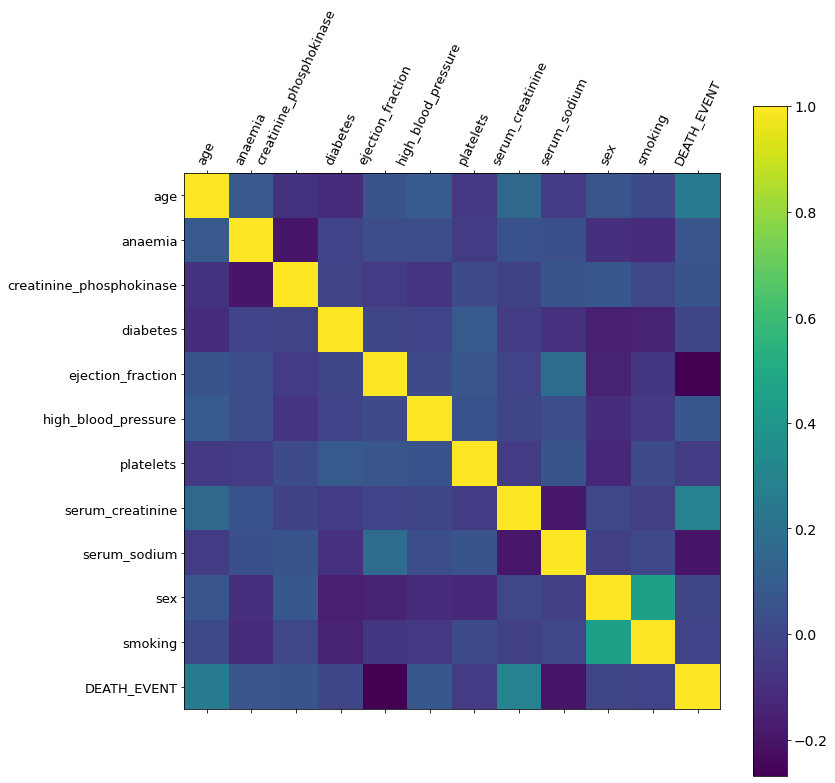

In [28]:
f = plt.figure(
    figsize=(12, 12)
)

plt.matshow(
    df.corr(), 
    fignum=f.number
)

plt.xticks(
    range(df.shape[1]), 
    df.columns, 
    fontsize=13, 
    rotation=65
)

plt.yticks(range(df.shape[1]), df.columns, fontsize=13)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)

<a id="2"></a>
<h2 style='background:purple; border:0; color:white'><center>2. Data transformations<center><h2>

In [29]:
X = df.copy()
y = X['DEATH_EVENT']
X = X.drop(['DEATH_EVENT'], axis=1)

In [30]:
pca = PCA(
    n_components=3, 
    random_state=666
)

X = pd.DataFrame(pca.fit_transform(X))
X['target'] = y

X

,0,1,2,target
0,1641.970459,-0.243563,-2.630059,1
1,1.767555,7279.161053,3.636118,1
2,-101358.132264,-411.233448,-10.143738,1
3,-53358.142059,-457.867205,-20.735284,1
4,63641.866227,-437.285876,-10.911461,1
...,...,...,...,...
294,-108358.152473,-494.537805,0.650499,0
295,6642.271107,1236.553968,-2.826810,0
296,478642.315680,1361.987184,4.608993,0
297,-123357.581058,1861.117313,-9.088176,0


In [31]:
fig = px.scatter_3d(
    X, 
    x=0, 
    y=1,
    z=2, 
    color="target", 
    title='3d scatter for PCA',
    width=SCATTER_SIZE,
    height=SCATTER_SIZE
)

fig.show()

In [32]:
X = df.copy()
y = X['DEATH_EVENT']
X = X.drop(['DEATH_EVENT'], axis=1)

In [33]:
pca = PCA(
    n_components=2, 
    random_state=666
)

X = pd.DataFrame(pca.fit_transform(X))
X['target'] = y

X

,0,1,target
0,1641.970459,-0.243563,1
1,1.767555,7279.161053,1
2,-101358.132264,-411.233448,1
3,-53358.142059,-457.867205,1
4,63641.866227,-437.285876,1
...,...,...,...
294,-108358.152473,-494.537805,0
295,6642.271107,1236.553968,0
296,478642.315680,1361.987184,0
297,-123357.581058,1861.117313,0


In [34]:
fig = px.scatter(
    X, 
    x=0, 
    y=1,
    color="target", 
    title='2d scatter for PCA',
    width=SCATTER_SIZE,
    height=SCATTER_SIZE
)

fig.show()

In [35]:
X = df.copy()
y = X['DEATH_EVENT']
X = X.drop(['DEATH_EVENT'], axis=1)

Let's try unsupervised learning first and will use KMeans algorithm.

In [36]:
kmeans = KMeans(
    n_clusters=2, 
    random_state=666
).fit(X)

In [37]:
train = X.copy()
train['cluster'] = kmeans.labels_
train['target'] = y

train

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,cluster,target
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,0,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,0,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,0,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,0,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,0,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,0,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,1,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,0,0


In [38]:
print('Kmeans accuracy: ', accuracy_score(train['target'], train['cluster']))
print('Kmeans f1_score: ', f1_score(train['target'], train['cluster']))

Kmeans accuracy:  0.6220735785953178
Kmeans f1_score:  0.2981366459627329


In [39]:
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    ax= plt.subplot()
    sns.heatmap(
        cm, 
        annot=True, 
        ax=ax, 
        fmt='g'
    )

    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')

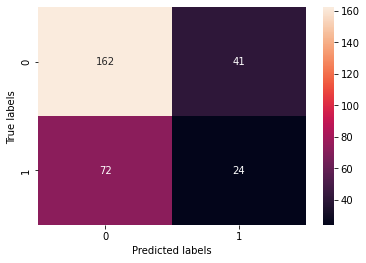

In [40]:
plot_confusion_matrix(
    train['target'], 
    train['cluster']
)

Now let's try to use COPOD anomaly detection model and check results.

In [41]:
response = train['target']
train = train.drop(['target', 'cluster'], axis=1)

In [42]:
clf = COPOD(
    contamination=0.3
)
clf.fit(train)

COPOD(contamination=0.3)

In [43]:
cluster = clf.predict(train)
train['cluster'] = cluster
train['target'] = response
train

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,cluster,target
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,1,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,0,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,0,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,0,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,0,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,0,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,1,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,0,0


In [44]:
train['cluster'].value_counts()

0    209
1     90
Name: cluster, dtype: int64

In [45]:
print('COPOD accuracy: ', accuracy_score(train['target'], train['cluster']))
print('COPOD f1_score: ', f1_score(train['target'], train['cluster']))

COPOD accuracy:  0.68561872909699
COPOD f1_score:  0.4946236559139785


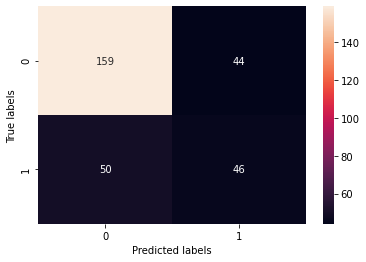

In [46]:
plot_confusion_matrix(
    train['target'], 
    train['cluster']
)

In [47]:
train = train.drop(['target', 'cluster'], axis=1)
train

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0
...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1


In [48]:
X_embedded = TSNE(
    n_components=2, 
    random_state=666
).fit_transform(train)
X_embedded = pd.DataFrame(X_embedded)

In [49]:
analysis = pd.DataFrame()
analysis['color'] = response
analysis['X'] = X_embedded[0]
analysis['Y'] = X_embedded[1]

fig = px.scatter(
    analysis, 
    x='X', 
    y='Y', 
    color="color", 
    title='TSNE for dataset',
    width=SCATTER_SIZE,
    height=SCATTER_SIZE
)

fig.show()

In [50]:
X_embedded = TSNE(
    n_components=3, 
    random_state=666
).fit_transform(train)
X_embedded = pd.DataFrame(X_embedded)

In [51]:
analysis = pd.DataFrame()
analysis['color'] = response
analysis['X'] = X_embedded[0]
analysis['Y'] = X_embedded[1]
analysis['Z'] = X_embedded[2]

fig = px.scatter_3d(
    analysis, 
    x='X', 
    y='Y',
    z='Z', 
    color="color", 
    title='3d scatter for TSNE',
    width=SCATTER_SIZE,
    height=SCATTER_SIZE
)

fig.show()

<a id="3"></a>
<h2 style='background:purple; border:0; color:white'><center>3. Modeling<center><h2>

Let's train Logistic Regression model as a quick baseline and check the results.

In [52]:
X, X_test, y, y_test = train_test_split(X, y, random_state=0, test_size=0.2, shuffle=True)

In [53]:
model = LogisticRegression(random_state=0)
model.fit(X, y)
preds = model.predict(X_test)

print('Logistic Regression ', accuracy_score(y_test, preds))

Logistic Regression  0.6833333333333333


Let's check a confusion matrix.

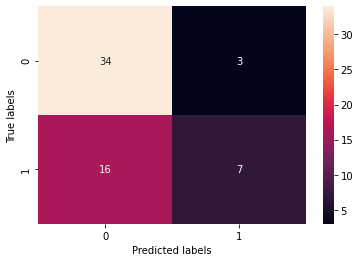

In [54]:
plot_confusion_matrix(
    y_test, 
    preds
)

We deal with imbalanced classification problem so accuracy is not really useful metric. Let's try f1-score and see results.

In [55]:
print('Logistic Regression f1-score', f1_score(y_test, preds))
print('Logistic Regression precision', precision_score(y_test, preds))
print('Logistic Regression recall', recall_score(y_test, preds))

Logistic Regression f1-score 0.42424242424242425
Logistic Regression precision 0.7
Logistic Regression recall 0.30434782608695654


Let's try to improve our f1-score and use LightGBM model.

In [56]:
model = LGBMClassifier(random_state=0)
model.fit(X, y)
preds = model.predict(X_test)

print('LightGBM f1-score', f1_score(y_test, preds))
print('LightGBM precision', precision_score(y_test, preds))
print('LightGBM recall', recall_score(y_test, preds))

LightGBM f1-score 0.4210526315789474
LightGBM precision 0.5333333333333333
LightGBM recall 0.34782608695652173


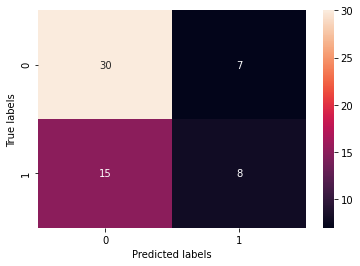

In [57]:
plot_confusion_matrix(y_test, preds)

The results are not really better. Let's try to drop features with absolute correlation with target less than 0.05.

In [58]:
for col in X.columns:
    if abs(X[col].corr(y)) < 0.05:
        X = X.drop([col], axis=1)
        X_test = X_test.drop([col], axis=1)

After removing some features  we have next set:

In [59]:
X

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,serum_creatinine,serum_sodium
134,81.0,0,4540,0,35,0,1.18,137
145,50.0,0,185,0,30,0,0.70,141
63,45.0,0,582,0,35,0,1.00,145
292,52.0,0,190,1,38,0,1.00,140
284,50.0,1,54,0,40,0,0.80,141
...,...,...,...,...,...,...,...,...
251,55.0,0,572,1,35,0,0.80,143
192,50.0,1,121,1,40,0,0.70,130
117,85.0,1,102,0,60,0,3.20,138
47,60.0,0,582,1,38,1,0.60,138


In [60]:
model = LGBMClassifier(random_state=0)
model.fit(X, y)
preds = model.predict(X_test)

print('LightGBM f1-score', f1_score(y_test, preds))
print('LightGBM precision', precision_score(y_test, preds))
print('LightGBM recall', recall_score(y_test, preds))

LightGBM f1-score 0.5365853658536586
LightGBM precision 0.6111111111111112
LightGBM recall 0.4782608695652174


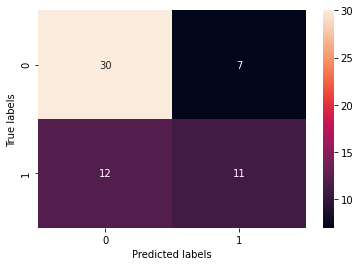

In [61]:
plot_confusion_matrix(y_test, preds)

Lets try XGBoost model.

In [62]:
model = XGBClassifier(random_state=666)
model.fit(X, y)
preds = model.predict(X_test)

print('XGBClassifier f1-score', f1_score(y_test, preds))
print('XGBClassifier precision', precision_score(y_test, preds))
print('XGBClassifier recall', recall_score(y_test, preds))

XGBClassifier f1-score 0.4
XGBClassifier precision 0.5833333333333334
XGBClassifier recall 0.30434782608695654


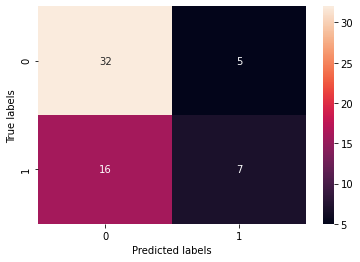

In [63]:
plot_confusion_matrix(y_test, preds)

The score for LightGBM became better. Lets do hyperparameters optimization next. We will use optuna for it.

<a id="3"></a>
<h2 style='background:purple; border:0; color:white'><center>4. Optimization<center><h2>

In [64]:
def create_model(trial):
    max_depth = trial.suggest_int("max_depth", 2, 6)
    n_estimators = trial.suggest_int("n_estimators", 1, 100)
    learning_rate = trial.suggest_uniform('learning_rate', 0.0000001, 1)
    num_leaves = trial.suggest_int("num_leaves", 2, 5000)
    min_child_samples = trial.suggest_int('min_child_samples', 3, 200)
    model = LGBMClassifier(
        learning_rate=learning_rate, 
        n_estimators=n_estimators, 
        max_depth=max_depth,
        num_leaves=num_leaves, 
        min_child_samples=min_child_samples,
        random_state=666
    )
    return model

sampler = TPESampler(seed=666)
def objective(trial):
    model = create_model(trial)
    model.fit(X, y)
    preds = model.predict(X_test)
    return f1_score(y_test, preds)

study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=200)

lgb_params = study.best_params
lgb_params['random_state'] = 666
lgb = LGBMClassifier(**lgb_params)
lgb.fit(X, y)
preds = lgb.predict(X_test)

print('Optimized LightGBM: ', accuracy_score(y_test, preds))
print('Optimized LightGBM f1-score', f1_score(y_test, preds))
print('Optimized LightGBM precision', precision_score(y_test, preds))
print('Optimized LightGBM recall', recall_score(y_test, preds))

[I 2020-12-01 00:00:12,993] Trial 0 finished with value: 0.42424242424242425 and parameters: {'max_depth': 6, 'n_estimators': 3, 'learning_rate': 0.8441866584317702, 'num_leaves': 2880, 'min_child_samples': 73}. Best is trial 0 with value: 0.42424242424242425.
[I 2020-12-01 00:00:13,017] Trial 1 finished with value: 0.33333333333333337 and parameters: {'max_depth': 3, 'n_estimators': 31, 'learning_rate': 0.9514579623005436, 'num_leaves': 1117, 'min_child_samples': 54}. Best is trial 0 with value: 0.42424242424242425.
[I 2020-12-01 00:00:13,043] Trial 2 finished with value: 0.36363636363636365 and parameters: {'max_depth': 6, 'n_estimators': 96, 'learning_rate': 0.2811685632759463, 'num_leaves': 2787, 'min_child_samples': 66}. Best is trial 0 with value: 0.42424242424242425.
[I 2020-12-01 00:00:13,062] Trial 3 finished with value: 0.0 and parameters: {'max_depth': 2, 'n_estimators': 47, 'learning_rate': 0.7670642351401253, 'num_leaves': 3143, 'min_child_samples': 144}. Best is trial 0 w

Optimized LightGBM:  0.8
Optimized LightGBM f1-score 0.7142857142857143
Optimized LightGBM precision 0.7894736842105263
Optimized LightGBM recall 0.6521739130434783


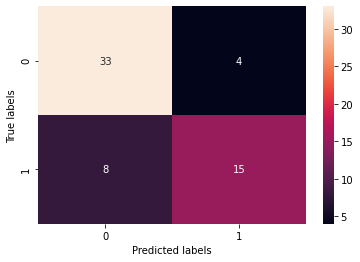

In [65]:
plot_confusion_matrix(y_test, preds)

We can see that f1-score became better.

Let's do postprocessing based on data visualization part.

In [66]:
check = X_test.copy()
check['preds'] = preds
check['preds_fixed'] = preds

check.loc[check['age']>90, 'preds_fixed'] = 1
check.loc[check['age']<42, 'preds_fixed'] = 0
check.loc[check['age'].isin([66, 67, 78, 79]), 'preds_fixed'] = 0
check.loc[check['ejection_fraction']<17, 'preds_fixed'] = 1
check.loc[check['serum_creatinine']>6.1, 'preds_fixed'] = 1

In [67]:
preds = check['preds_fixed']

print('Postprocessed accuracy: ', accuracy_score(y_test, preds))
print('Postprocessed f1-score', f1_score(y_test, preds))
print('Postprocessed precision', precision_score(y_test, preds))
print('Postprocessed recall', recall_score(y_test, preds))

Postprocessed accuracy:  0.8333333333333334
Postprocessed f1-score 0.7727272727272727
Postprocessed precision 0.8095238095238095
Postprocessed recall 0.7391304347826086


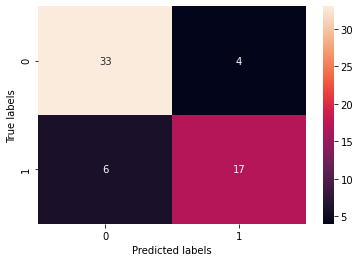

In [68]:
plot_confusion_matrix(y_test, preds)

We can see that this manipulations helped to increase score.

Now we will try to improve model using Recursive feature elimination and find best the set of features for empty LightGBM model.

In [69]:
for i in range(1, len(X.columns)+1):
    rfe = RFE(
        estimator=DecisionTreeClassifier(
            random_state=0
        ), 
        n_features_to_select=i
    )
    pipeline = Pipeline(
        steps=[
            ('s', rfe),
            ('m', LGBMClassifier(random_state=0))
        ]
    )
    pipeline.fit(X, y)
    preds = pipeline.predict(X_test)
    
    print('Number of features: ', i)
    print('LightGBM f1-score', f1_score(y_test, preds))

Number of features:  1
LightGBM f1-score 0.2
Number of features:  2
LightGBM f1-score 0.5263157894736841
Number of features:  3
LightGBM f1-score 0.4210526315789474
Number of features:  4
LightGBM f1-score 0.5
Number of features:  5
LightGBM f1-score 0.3888888888888889
Number of features:  6
LightGBM f1-score 0.4210526315789474
Number of features:  7
LightGBM f1-score 0.46153846153846156
Number of features:  8
LightGBM f1-score 0.5365853658536586


We can see good scores for N_features = 2 and N_features = 8. For second case we already know results of optimization. Let's check the same for N_feauters = 2.

In [70]:
def create_model(trial):
    rfe = RFE(
        estimator=DecisionTreeClassifier(random_state=0), 
        n_features_to_select=2
    )
    max_depth = trial.suggest_int("max_depth", 2, 8)
    n_estimators = trial.suggest_int("n_estimators", 1, 200)
    learning_rate = trial.suggest_uniform('learning_rate', 0.0000001, 1)
    num_leaves = trial.suggest_int("num_leaves", 2, 5000)
    min_child_samples = trial.suggest_int('min_child_samples', 3, 200)
    model = Pipeline(
        steps=[
            ('s', rfe), 
            ('m', 
             LGBMClassifier(
                 learning_rate=learning_rate, 
                 n_estimators=n_estimators, 
                 max_depth=max_depth, 
                 num_leaves=num_leaves, 
                 min_child_samples=min_child_samples, 
                 random_state=0
             )
            )
        ]
    )
    return model

def objective(trial):
    model = create_model(trial)
    model.fit(X, y)
    preds = model.predict(X_test)
    return f1_score(y_test, preds)

study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=150)

lgb_params = study.best_params
lgb_params['random_state'] = 666
lgb = LGBMClassifier(**lgb_params)
rfe = RFE(
    estimator=DecisionTreeClassifier(
        random_state=666
    ), 
    n_features_to_select=2
)
model = Pipeline(
    steps=[
        ('s',rfe), 
        ('m', lgb)
    ]
)
model.fit(X, y)
preds = model.predict(X_test)

print('Optimized LightGBM: ', accuracy_score(y_test, preds))
print('Optimized LightGBM f1-score', f1_score(y_test, preds))
print('Optimized LightGBM precision', precision_score(y_test, preds))
print('Optimized LightGBM recall', recall_score(y_test, preds))

[I 2020-12-01 00:00:31,506] Trial 0 finished with value: 0.14814814814814817 and parameters: {'max_depth': 5, 'n_estimators': 78, 'learning_rate': 0.2913020446250291, 'num_leaves': 2150, 'min_child_samples': 91}. Best is trial 0 with value: 0.14814814814814817.
[I 2020-12-01 00:00:31,549] Trial 1 finished with value: 0.0 and parameters: {'max_depth': 5, 'n_estimators': 140, 'learning_rate': 0.1913686488011405, 'num_leaves': 1409, 'min_child_samples': 178}. Best is trial 0 with value: 0.14814814814814817.
[I 2020-12-01 00:00:31,601] Trial 2 finished with value: 0.0 and parameters: {'max_depth': 5, 'n_estimators': 169, 'learning_rate': 0.7230665204579155, 'num_leaves': 4887, 'min_child_samples': 96}. Best is trial 0 with value: 0.14814814814814817.
[I 2020-12-01 00:00:31,647] Trial 3 finished with value: 0.3888888888888889 and parameters: {'max_depth': 5, 'n_estimators': 84, 'learning_rate': 0.7912352593110032, 'num_leaves': 4315, 'min_child_samples': 72}. Best is trial 3 with value: 0.3

Optimized LightGBM:  0.7166666666666667
Optimized LightGBM f1-score 0.6046511627906976
Optimized LightGBM precision 0.65
Optimized LightGBM recall 0.5652173913043478


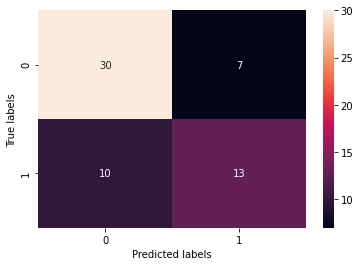

In [71]:
plot_confusion_matrix(y_test, preds)